# Dataset Exploration and Visualization
This notebook loads the house_prices.csv dataset and performs exploratory data analysis (EDA) including:
- Data loading and inspection
- Summary statistics
- Scatter plots, histograms, and box plots
- Outlier detection

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load the Dataset

In [5]:
# Load the house_prices.csv dataset
csv_path = 'house_prices.csv'

try:
    df = pd.read_csv(csv_path)
    print(f'Successfully loaded {csv_path}')
except FileNotFoundError:
    print(f'{csv_path} not found. Loading Iris dataset from seaborn as fallback...')
    df = sns.load_dataset('iris')
    print('Loaded Iris dataset from seaborn')

print(f'\nDataset loaded successfully!')

Successfully loaded house_prices.csv

Dataset loaded successfully!


## 2. Data Inspection

In [6]:
# Check the shape of the dataset
print('Dataset Shape:')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f'\nShape: {df.shape}')


Dataset Shape:
Rows: 21613, Columns: 21

Shape: (21613, 21)


In [7]:
# Display column names
print('\nColumn Names:')
print(df.columns.tolist())


Column Names:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [8]:
# Display the first few rows
print('\nFirst 5 Rows:')
df.head()


First 5 Rows:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 3. Summary Statistics

In [9]:
# Get dataset info
print('\nDataset Info:')
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  object 
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  object 
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  floa

In [10]:
# Get descriptive statistics
print('\nDescriptive Statistics:')
df.describe()


Descriptive Statistics:


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.234303,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.766318,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,4.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## 4. Data Visualization

### 4.1 Scatter Plot - Relationships between Features

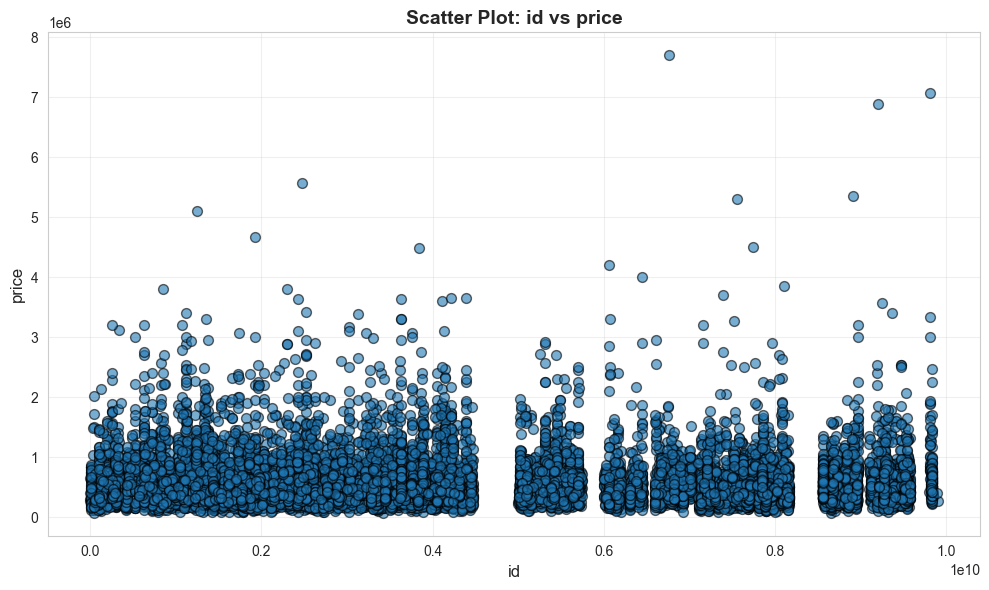

Scatter plot created: id vs price


In [11]:
# Get numeric columns for plotting
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) >= 2:
    # Scatter plot of first two numeric columns
    plt.figure(figsize=(10, 6))
    plt.scatter(df[numeric_cols[0]], df[numeric_cols[1]], alpha=0.6, edgecolors='k', s=50)
    plt.xlabel(numeric_cols[0], fontsize=12)
    plt.ylabel(numeric_cols[1], fontsize=12)
    plt.title(f'Scatter Plot: {numeric_cols[0]} vs {numeric_cols[1]}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'Scatter plot created: {numeric_cols[0]} vs {numeric_cols[1]}')
else:
    print('Not enough numeric columns for scatter plot')

### 4.2 Pair Plot - Relationships between All Features

<Figure size 1400x1200 with 0 Axes>

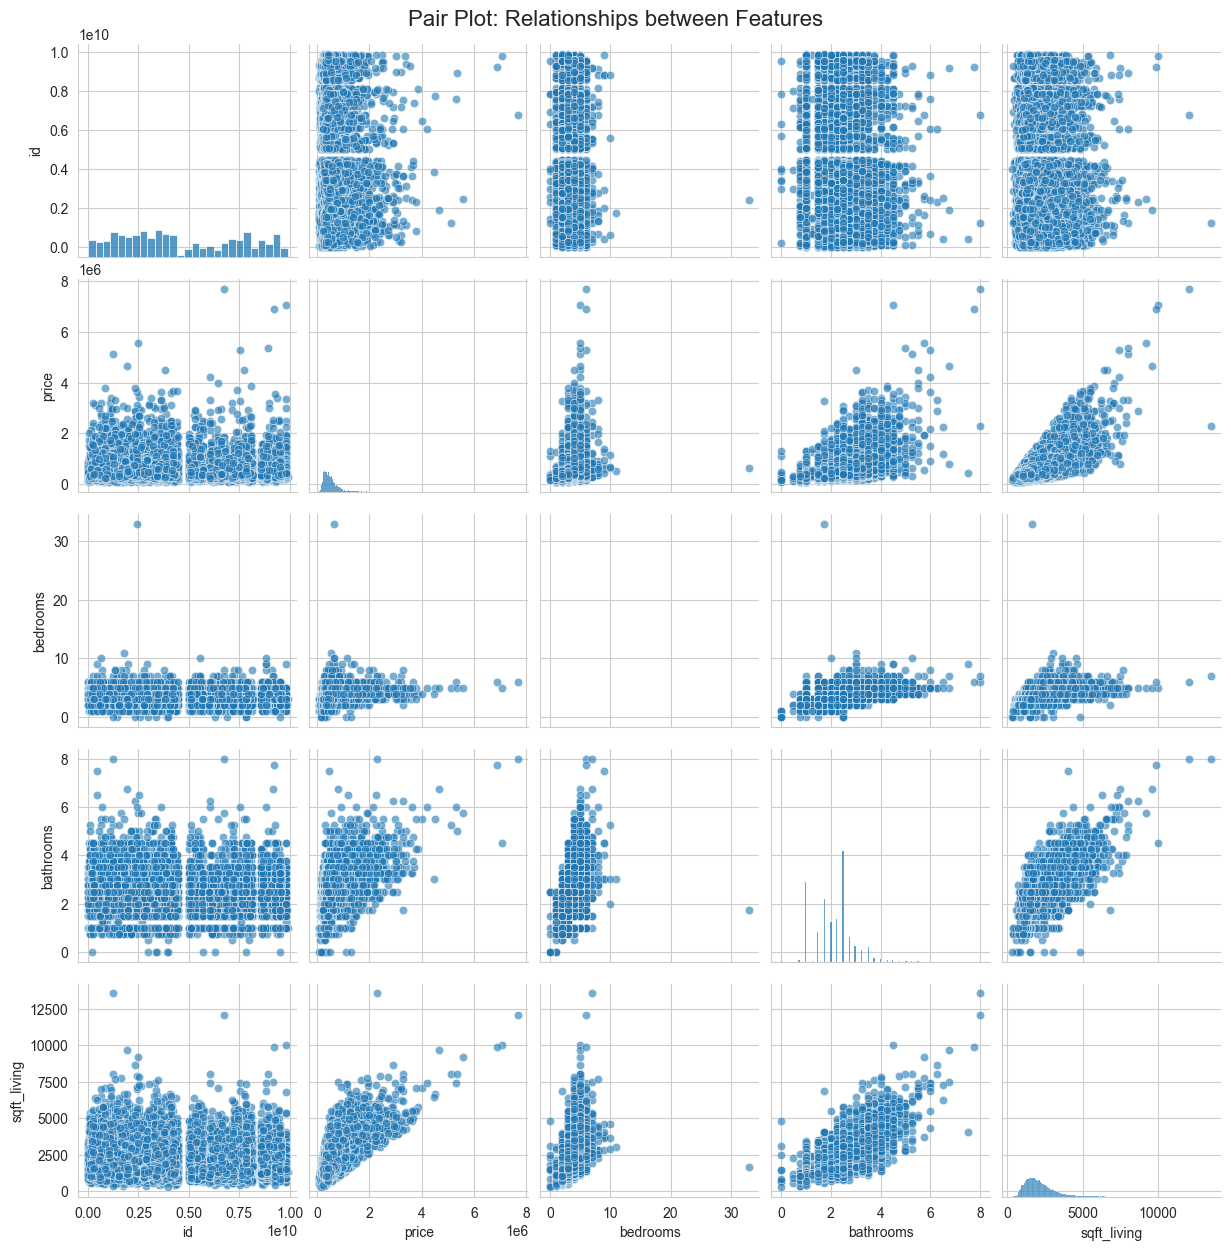

Pair plot created for columns: ['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living']


In [12]:
# Create a pair plot for multiple features
if len(numeric_cols) > 1:
    # Use first 5 numeric columns or all if fewer than 5
    cols_to_plot = numeric_cols[:min(5, len(numeric_cols))]
    plt.figure(figsize=(14, 12))
    pairplot = sns.pairplot(df[cols_to_plot], diag_kind='hist', plot_kws={'alpha': 0.6})
    plt.suptitle('Pair Plot: Relationships between Features', fontsize=16, y=1.00)
    plt.show()
    print(f'Pair plot created for columns: {cols_to_plot}')

### 4.3 Histograms - Value Distributions

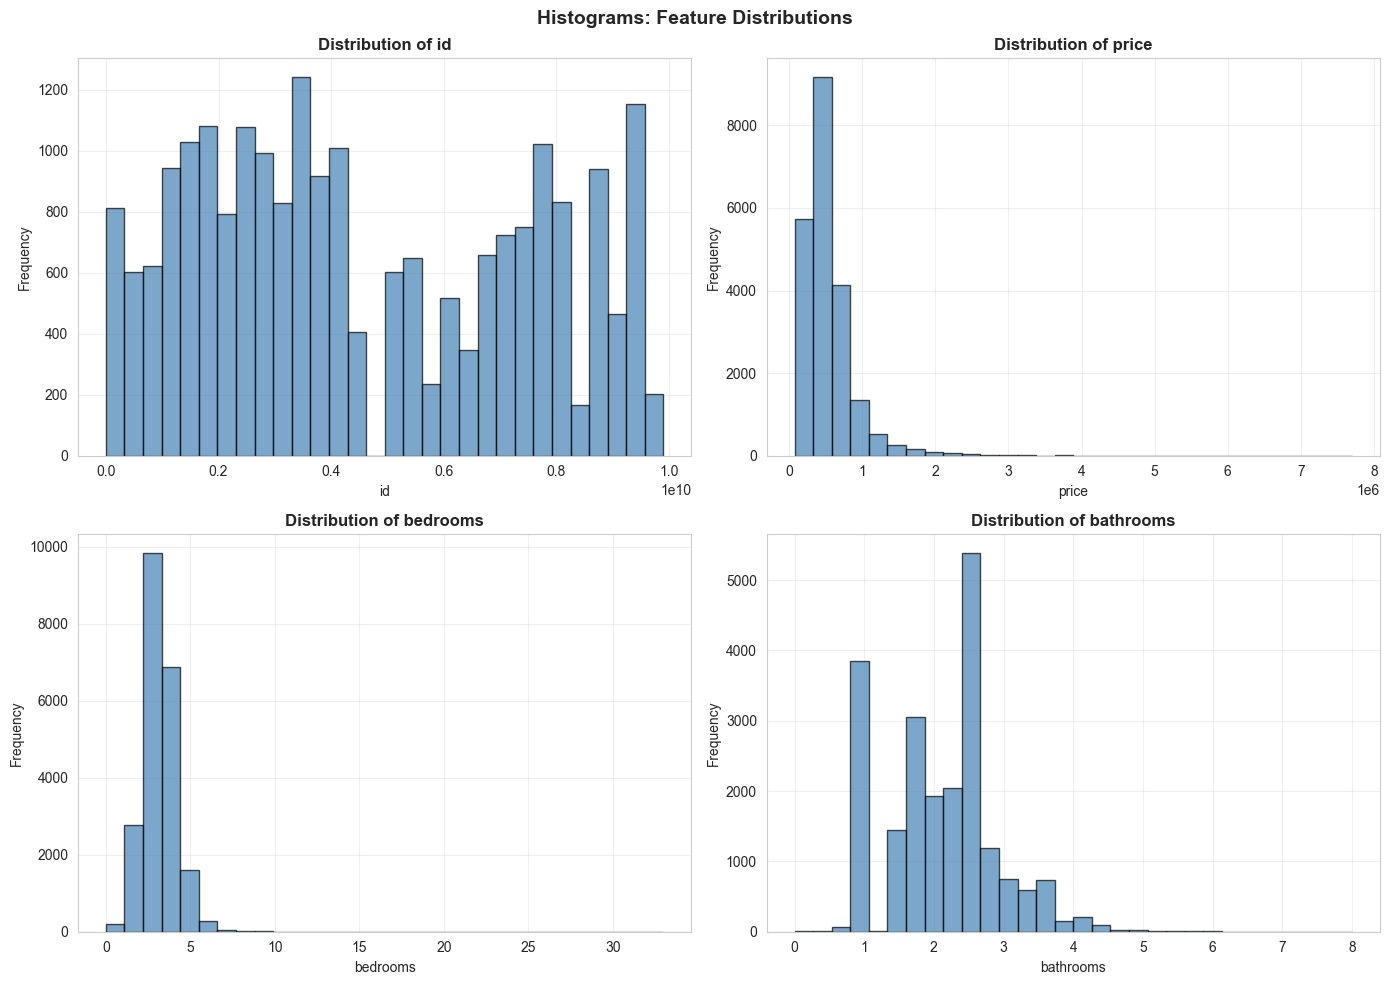

Histograms created for: ['id', 'price', 'bedrooms', 'bathrooms']


In [13]:
# Create histograms for numeric columns
if len(numeric_cols) > 0:
    # Display histograms for first 4 columns
    cols_to_hist = numeric_cols[:min(4, len(numeric_cols))]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(cols_to_hist):
        axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(cols_to_hist), 4):
        axes[idx].axis('off')
    
    plt.suptitle('Histograms: Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Histograms created for: {cols_to_hist}')

### 4.4 Box Plots - Identifying Outliers

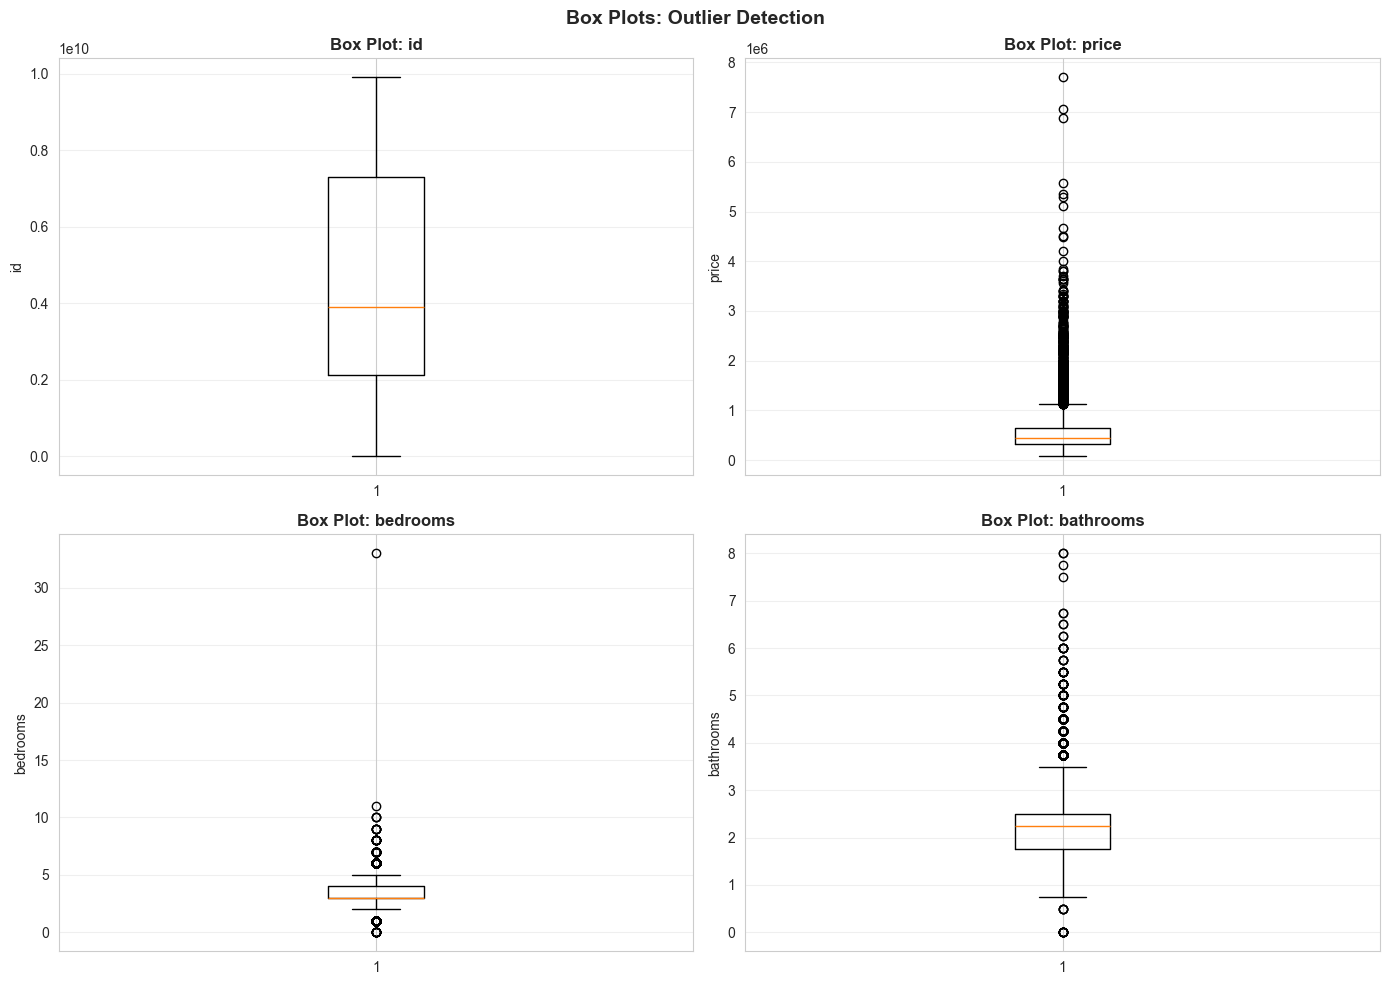

Box plots created for: ['id', 'price', 'bedrooms', 'bathrooms']


In [14]:
# Create box plots for outlier detection
if len(numeric_cols) > 0:
    cols_to_box = numeric_cols[:min(4, len(numeric_cols))]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(cols_to_box):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(col, fontsize=10)
        axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Hide unused subplots
    for idx in range(len(cols_to_box), 4):
        axes[idx].axis('off')
    
    plt.suptitle('Box Plots: Outlier Detection', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Box plots created for: {cols_to_box}')

### 4.5 Correlation Heatmap

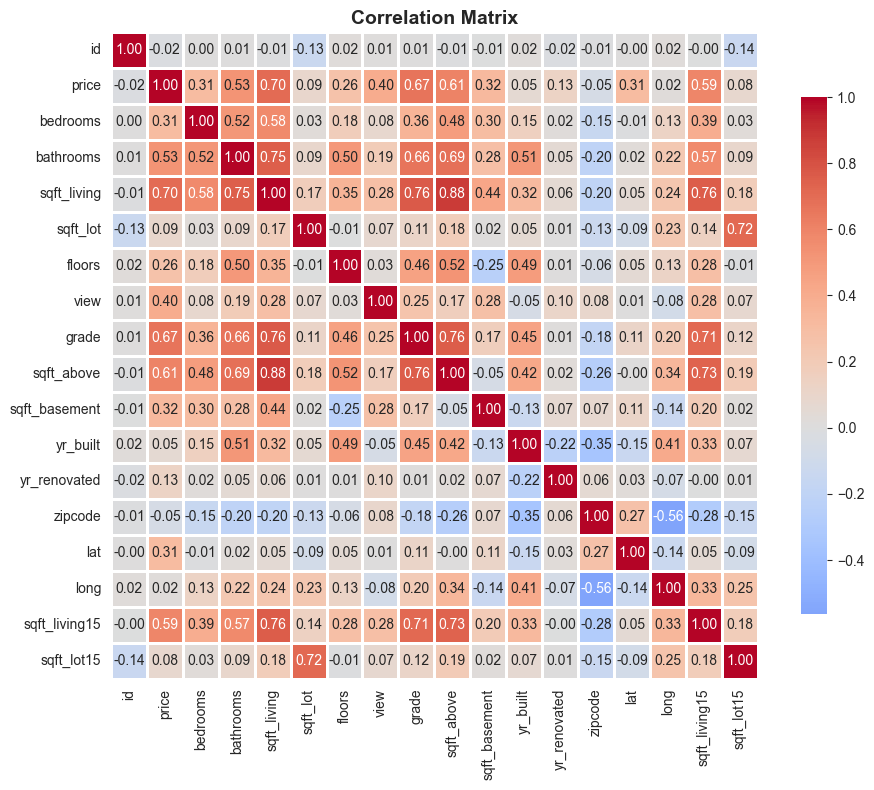

Correlation heatmap created


In [15]:
# Create a correlation heatmap
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('Correlation heatmap created')

## 5. Summary of Findings

In [16]:
print('='*60)
print('EXPLORATORY DATA ANALYSIS SUMMARY')
print('='*60)
print(f'\n📊 Dataset Overview:')
print(f'   - Total Rows: {df.shape[0]}')
print(f'   - Total Columns: {df.shape[1]}')
print(f'   - Numeric Columns: {len(numeric_cols)}')

print(f'\n📈 Missing Values:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('   - No missing values detected')
else:
    print(missing[missing > 0])

print(f'\n📉 Data Types:')
print(df.dtypes)

print(f'\n✅ Analysis Complete!')
print('='*60)

EXPLORATORY DATA ANALYSIS SUMMARY

📊 Dataset Overview:
   - Total Rows: 21613
   - Total Columns: 21
   - Numeric Columns: 18

📈 Missing Values:
   - No missing values detected

📉 Data Types:
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront        object
view               int64
condition         object
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

✅ Analysis Complete!
